## Load Dataset from Kaggle - Beijing PM2.5 Dataset

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("djhavera/beijing-pm25-data-data-set")

print("Path to dataset files:", path)

100%|██████████| 505k/505k [00:00<00:00, 74.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/djhavera/beijing-pm25-data-data-set/versions/1


In [58]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))

print("Dataset Loaded. Shape:", df.shape)

Dataset Loaded. Shape: (43824, 13)


## Review of Dataset

No      : Row index (not useful for modeling) \
year    : Year of observation\
month   : Month (captures seasonal trends)\
day     : Day of month\
hour    : Hour of day (captures daily patterns)\
TEMP    : Temperature (°C) → affects pollution dispersion\
DEWP    : Dew point (°C) → indicates humidity level\
PRES    : Atmospheric pressure (hPa) → high pressure traps pollution\
cbwd    : Wind direction (categorical, e.g., NW, SE)\
Iws     : Wind speed → higher wind reduces pollution\
Is      : Snow hours → helps remove pollutants\
Ir      : Rain hours → washes out pollution

pm2.5   : Target variable → air pollution level (µg/m³)

In [59]:
df.head(5)

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## Data Cleaning (Interpolating & Encoding)

In [60]:
from sklearn.preprocessing import LabelEncoder

# 1. Create a proper datetime column and set it as index
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df = df.set_index('datetime').sort_index()

# 2. Handle missing values in time series using time-based interpolation
df['pm2.5'] = df['pm2.5'].interpolate(method='time')

# Drop any remaining rows with missing values
df = df.dropna()

# 3. Convert categorical wind direction (cbwd) into numerical values
le = LabelEncoder()
df['cbwd_encoded'] = le.fit_transform(df['cbwd'])

print("Data cleaned. Total missing values:", df.isna().sum().sum())
display(df.head())

Data cleaned. Total missing values: 0


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,cbwd_encoded
datetime,,,,,,,,,,,,,,
2010-01-02 00:00:00,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0,2
2010-01-02 01:00:00,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0,2
2010-01-02 02:00:00,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0,2
2010-01-02 03:00:00,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0,2
2010-01-02 04:00:00,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0,2


## Visualising

/tmp/ipykernel_9487/4190308152.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['pm2.5'].resample('M').mean().plot(color='#d62728', linewidth=2)


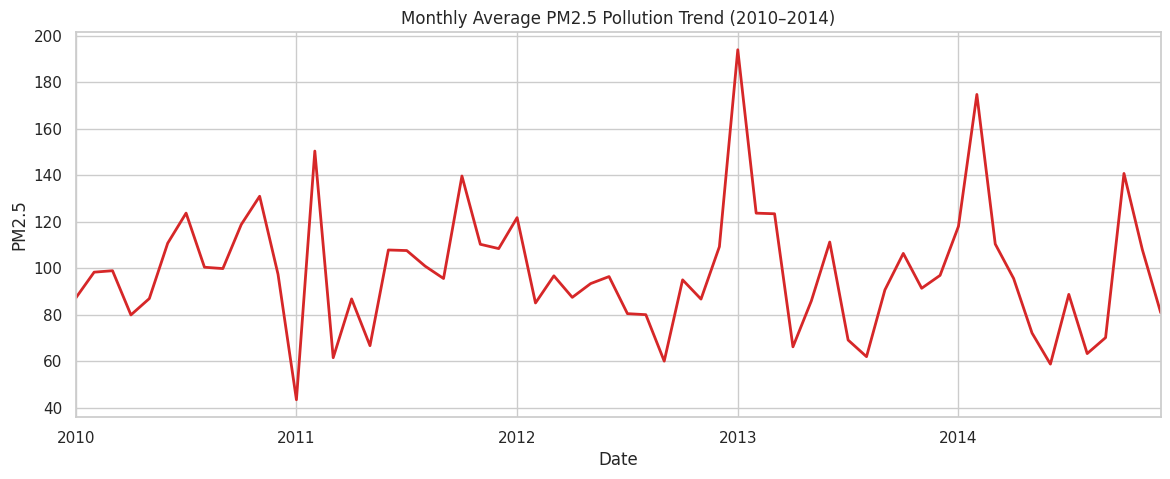

In [5]:
# Plot 1: Monthly Trend
plt.figure(figsize=(14, 5))
df['pm2.5'].resample('M').mean().plot(color='#d62728', linewidth=2)
plt.title('Monthly Average PM2.5 Pollution Trend (2010–2014)')
plt.ylabel('PM2.5')
plt.xlabel('Date')
plt.show()

/tmp/ipykernel_9487/279093618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')


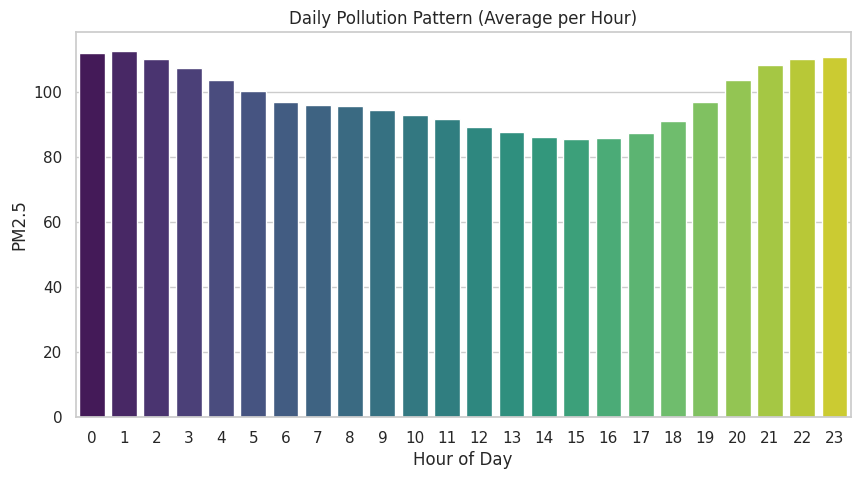

In [6]:
# Plot 2: Daily Pattern (Hourly Average)
plt.figure(figsize=(10, 5))
hourly_avg = df.groupby(df.index.hour)['pm2.5'].mean()
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='viridis')
plt.title('Daily Pollution Pattern (Average per Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('PM2.5')
plt.show()

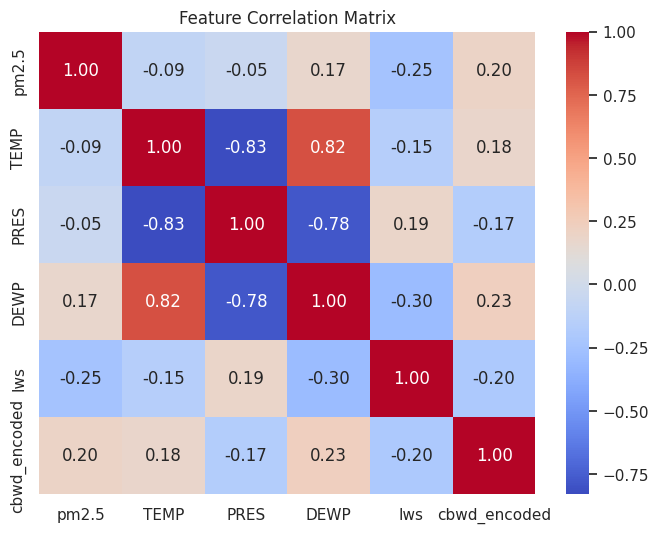

In [7]:
# Plot 3: Correlation Heatmap
plt.figure(figsize=(8, 6))
cols = ['pm2.5', 'TEMP', 'PRES', 'DEWP', 'Iws', 'cbwd_encoded']
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

## Selecting Top 6 Features to train the model

/tmp/ipykernel_9487/860563681.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F_Score', y='Feature', data=ranking, palette='magma')


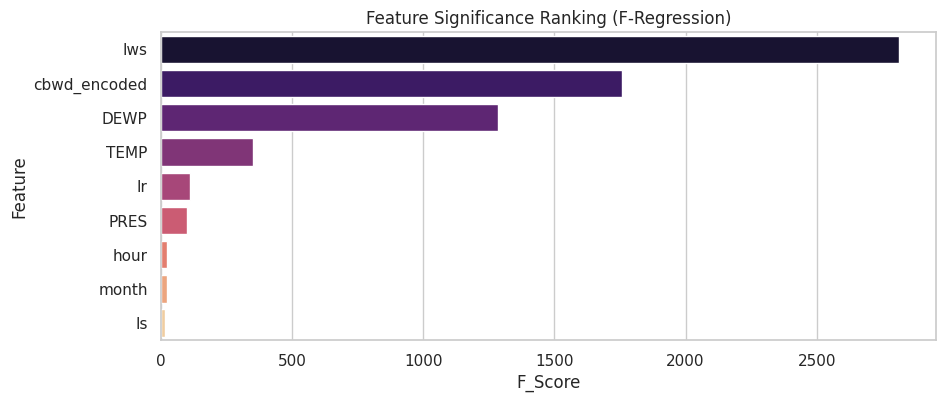

Selected Features: ['Iws', 'cbwd_encoded', 'DEWP', 'TEMP', 'Ir', 'PRES']


In [8]:
from sklearn.feature_selection import SelectKBest, f_regression

# Define candidate features
candidate_features = ['TEMP', 'PRES', 'DEWP', 'Iws', 'Is', 'Ir', 'cbwd_encoded', 'month', 'hour']
X_all = df[candidate_features]
y = df['pm2.5']

# Compute F-scores using regression
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_all, y)

# Display feature ranking
ranking = pd.DataFrame({
    'Feature': candidate_features,
    'F_Score': selector.scores_
}).sort_values(by='F_Score', ascending=False).reset_index(drop=True)

# Visualize feature importance ranking
plt.figure(figsize=(10, 4))
sns.barplot(x='F_Score', y='Feature', data=ranking, palette='magma')
plt.title('Feature Significance Ranking (F-Regression)')
plt.show()

# Select top 5 features
top_features = ranking['Feature'].head(6).tolist()
print("Selected Features:", top_features)

In [9]:
# Prepare final dataset
X_final = df[top_features]
y_final = df['pm2.5']
X_final.head()

,Iws,cbwd_encoded,DEWP,TEMP,Ir,PRES
datetime,,,,,,
2010-01-02 00:00:00,1.79,2,-16,-4.0,0,1020.0
2010-01-02 01:00:00,2.68,2,-15,-4.0,0,1020.0
2010-01-02 02:00:00,3.57,2,-11,-5.0,0,1021.0
2010-01-02 03:00:00,5.36,2,-7,-5.0,0,1022.0
2010-01-02 04:00:00,6.25,2,-7,-5.0,0,1022.0


In [10]:
y.head()

,pm2.5
datetime,
2010-01-02 00:00:00,129.0
2010-01-02 01:00:00,148.0
2010-01-02 02:00:00,159.0
2010-01-02 03:00:00,181.0
2010-01-02 04:00:00,138.0


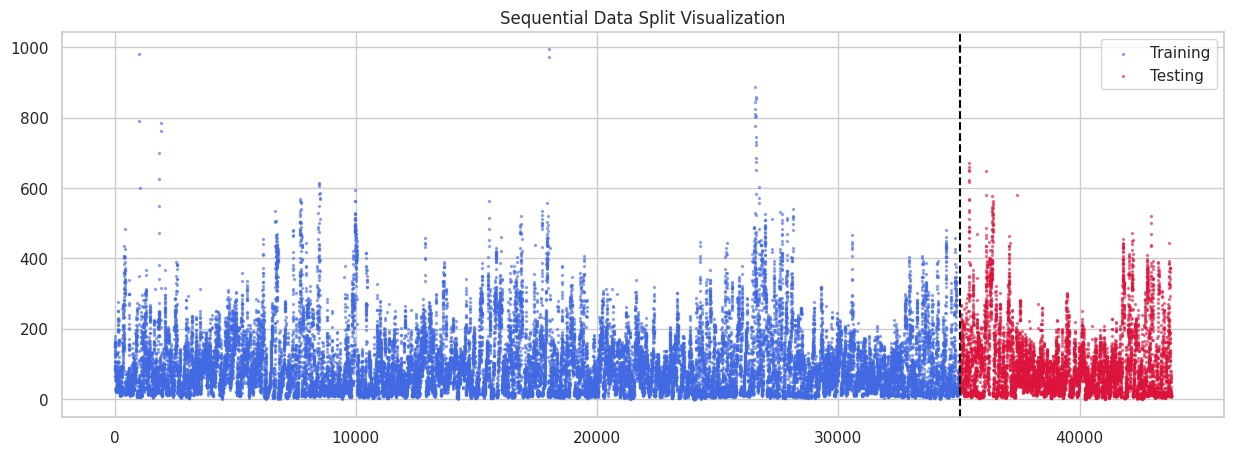

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Sequential train-test split (80:20) without shuffling (important for time series)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, shuffle=False
)

# Apply Min-Max scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Visualize train-test split
plt.figure(figsize=(15, 5))
plt.scatter(range(len(y_train)), y_train, color='royalblue', s=2, alpha=0.5, label='Training')
plt.scatter(range(len(y_train), len(y_train) + len(y_test)), y_test,
            color='crimson', s=2, alpha=0.5, label='Testing')

# Vertical line to show split point
plt.axvline(x=len(y_train), color='black', linestyle='--')

plt.title('Sequential Data Split Visualization')
plt.legend()
plt.show()

## Checking model - Linear Regression

In [12]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [13]:
print("Linear Regression Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

Linear Regression Metrics:
MSE: 6876.043909710419
MAE: 57.88456555636642
R2 Score: 0.2188402160541114


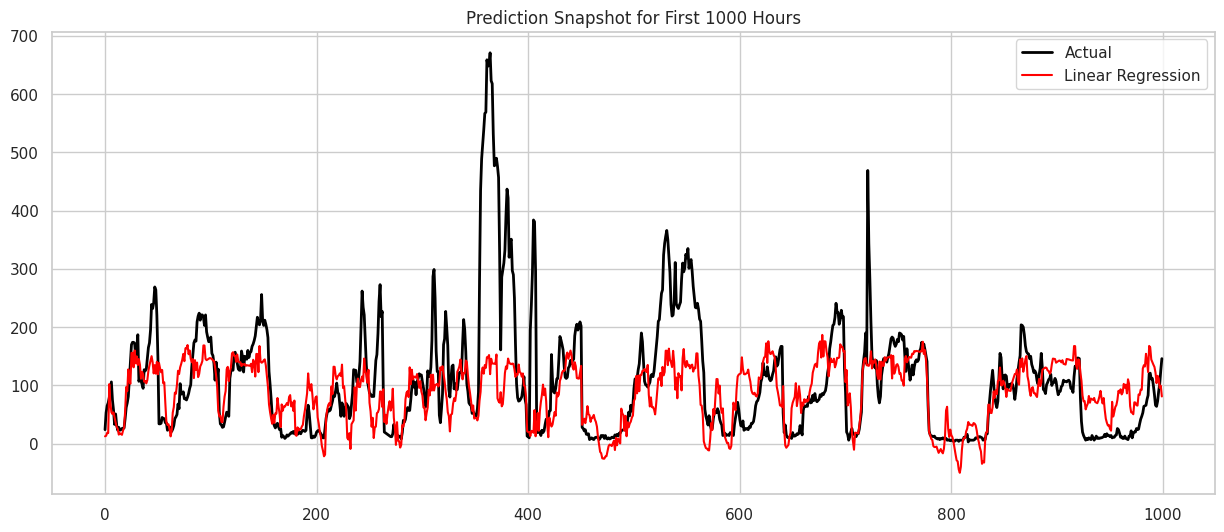

In [14]:
# 1. Prediction Line Chart (First 1000 Hours Sample)
limit = 1000
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:limit], label='Actual', color='black', linewidth=2)
plt.plot(y_pred_lr[:limit], label='Linear Regression', linestyle='-', color='red')
plt.title('Prediction Snapshot for First 1000 Hours')
plt.legend()
plt.show()

In [15]:
coefficients = lr.coef_

feature_importance = pd.Series(coefficients, index=X_train.columns)

feature_importance_sorted = feature_importance.sort_values(key=np.abs, ascending=False)

print("\nFeature Importance (Linear Regression):")
print(feature_importance_sorted)


Feature Importance (Linear Regression):
TEMP           -352.628750
DEWP            248.335112
Ir             -223.957236
Iws            -122.223405
PRES            -94.091909
cbwd_encoded     37.108066
dtype: float64


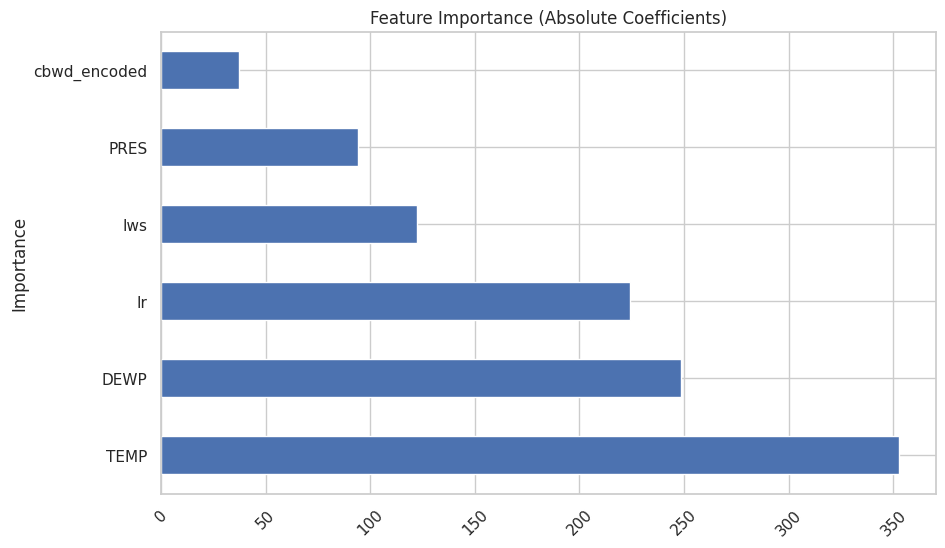

In [16]:
plt.figure(figsize=(10, 6))
feature_importance_sorted.abs().plot(kind='barh')
plt.title('Feature Importance (Absolute Coefficients)')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

## Checking model - Random Forest

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

In [18]:
print("Random Forest Metrics:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Random Forest Metrics:
MSE: 6649.504006545469
MAE: 56.23213218709196
R2 Score: 0.24457650630111605


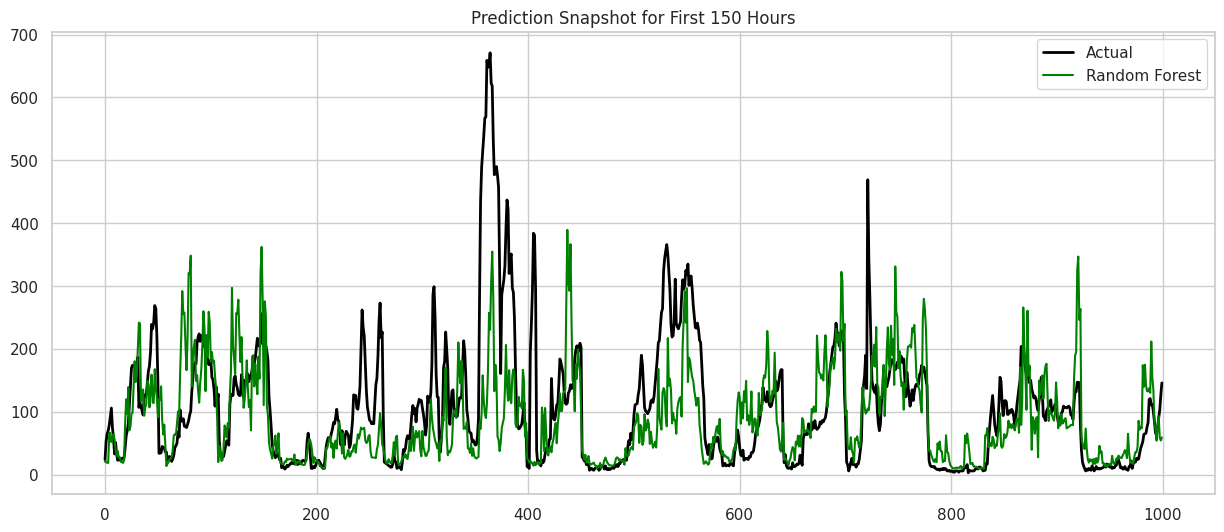

In [19]:
# 1. Prediction Line Chart (First 1000 Hours Sample)
limit = 1000
plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:limit], label='Actual', color='black', linewidth=2)
plt.plot(y_pred_rf[:limit], label='Random Forest', linestyle='-', color='green')
plt.title('Prediction Snapshot for First 150 Hours')
plt.legend()
plt.show()

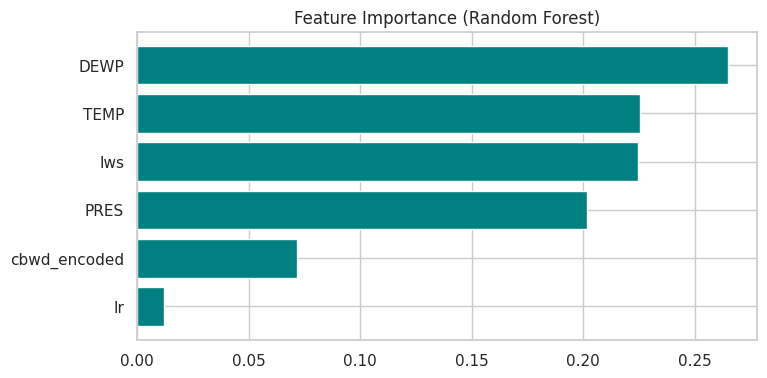

In [20]:
# 2. Feature Importance (Random Forest)
imp_df = pd.DataFrame({
    'Feature': top_features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='teal')
plt.title('Feature Importance (Random Forest)')
plt.show()

## Checking Model - Neural ODE

In [21]:
!pip install torchdiffeq

### Getting features

In [171]:
new_df = df.copy()
new_df = new_df.drop(['cbwd','year','month','day','hour','No','Is'],axis=1)
new_df

,pm2.5,DEWP,TEMP,PRES,Iws,Ir,cbwd_encoded
datetime,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,1.79,0,2
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,2.68,0,2
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,3.57,0,2
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,5.36,0,2
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,6.25,0,2
...,...,...,...,...,...,...,...
2014-12-31 19:00:00,8.0,-23,-2.0,1034.0,231.97,0,1
2014-12-31 20:00:00,10.0,-22,-3.0,1034.0,237.78,0,1
2014-12-31 21:00:00,10.0,-22,-3.0,1034.0,242.70,0,1


In [172]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
y_raw = new_df["pm2.5"].values.astype(np.float32).reshape(-1, 1)  # only pm2.5
X_raw = new_df[top_features].values.astype(np.float32)


# Separate scalers
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_raw)   # shape (N, 6)
y_scaled = scaler_y.fit_transform(y_raw)   # shape (N, 1)

### Create Sequences

In [181]:
# Create sequences: X uses all features, y uses only pm2.5
def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

seq_len = 20
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_len)

# X_seq shape: (N, 20, 6)
# y_seq shape: (N, 1)

X_seq = torch.tensor(X_seq)
y_seq = torch.tensor(y_seq)

### Train Test Split

In [182]:
from torch.utils.data import DataLoader, TensorDataset


train_size = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=False)

### Neural ODE

In [183]:
import torch.nn as nn
from torchdiffeq import odeint

# ODE function (dh/dt = f(h,θ))
class ODEFunc(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 32),
            nn.Tanh(),
            nn.Linear(32, dim)
        )

    def forward(self, t, h):
        return self.net(h)


# Neural ODE model
class NeuralODE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.GRU(input_dim,input_dim, batch_first=True)#
        self.func = ODEFunc(input_dim)
        self.fc = nn.Linear(input_dim, 1)

    def forward(self, x):
        _, h = self.encoder(x)
        h0 = h.squeeze(0)

        t = torch.linspace(0, 1, 5).to(x.device)

        h_t = odeint(self.func, h0, t)
        h_final = h_t[-1]

        out = self.fc(h_final)
        return out


# Take last timestep as initial state
# Solve ODE from t=0 → t=1
# Predict next value

In [184]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dim = X_seq.shape[2]  # number of features
model = NeuralODE(input_dim=dim).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

### Training Loop

In [185]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred,yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 4.4708
Epoch 2, Loss: 3.0580
Epoch 3, Loss: 2.9919
Epoch 4, Loss: 3.0084
Epoch 5, Loss: 3.0554
Epoch 6, Loss: 3.1282
Epoch 7, Loss: 3.2288
Epoch 8, Loss: 3.3339
Epoch 9, Loss: 3.3982
Epoch 10, Loss: 3.3970


### Prediction

In [186]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()

y_test_np = y_test.numpy()

In [187]:
y_pred_inv = scaler_y.inverse_transform(y_pred)
y_test_inv = scaler_y.inverse_transform(y_test_np)

### Evaluation

In [188]:
print("Neural ODE Metrics:")
print("MSE:", mean_squared_error(y_test_inv, y_pred_inv))
print("MAE:", mean_absolute_error(y_test_inv, y_pred_inv))
print("R2 Score:", r2_score(y_test_inv, y_pred_inv))

Neural ODE Metrics:
MSE: 12859.205078125
MAE: 97.6620864868164
R2 Score: -0.46039295196533203


### Visualisation

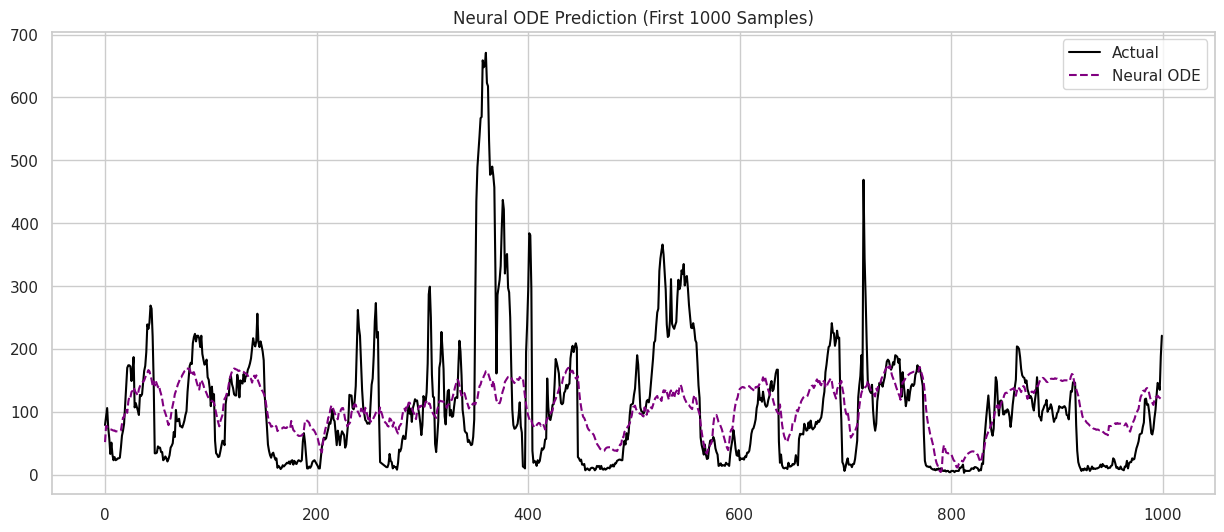

In [189]:
import matplotlib.pyplot as plt

limit = 1000

plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[:limit], label='Actual', color='black')
plt.plot(y_pred_inv[:limit], label='Neural ODE', linestyle='--', color='purple')

plt.title('Neural ODE Prediction (First 1000 Samples)')
plt.legend()
plt.show()

### Gradient based XAI

In [207]:
def compute_feature_importance(model, X_sample):
    model.eval()

    X_sample = X_sample.clone().detach().to(device)
    X_sample.requires_grad = True

    output = model(X_sample)

    output.sum().backward()

    grads = X_sample.grad.abs().cpu().numpy()
    time_importance = grads.mean(axis=2)

    importance = grads.mean(axis=1)

    return importance

In [208]:
sample = X_test[:10000].to(device)

importance = compute_feature_importance(model, sample)

feature_importance = importance.mean(axis=0)

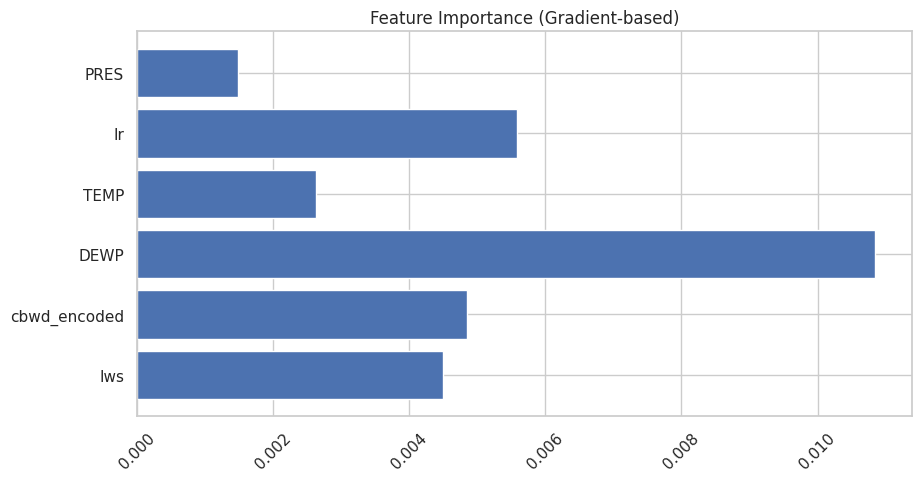

In [209]:
feature_names = top_features

plt.figure(figsize=(10,5))
plt.barh(feature_names, feature_importance)
plt.title("Feature Importance (Gradient-based)")
plt.xticks(rotation=45)
plt.show()

### SHAP

In [216]:
seq_len = X_test.shape[1]
num_features = X_test.shape[2]

def model_wrapper(x):
    x = torch.tensor(x, dtype=torch.float32).to(device)

    x = x.view(-1, seq_len, num_features)

    with torch.no_grad():
        out = model(x)

    return out.cpu().numpy().reshape(-1)

In [217]:
import shap

X_shap = X_test[:30].cpu().numpy().reshape(30, -1)

explainer = shap.KernelExplainer(model_wrapper, X_shap)
shap_values = explainer.shap_values(X_shap)

  0%|          | 0/30 [00:00<?, ?it/s]

In [218]:
shap_values = np.array(shap_values)

shap_values = shap_values.reshape(-1, seq_len, num_features)

In [226]:
feature_importance = np.abs(shap_values).mean(axis=1)  # avg over time

final_importance = feature_importance.mean(axis=0)

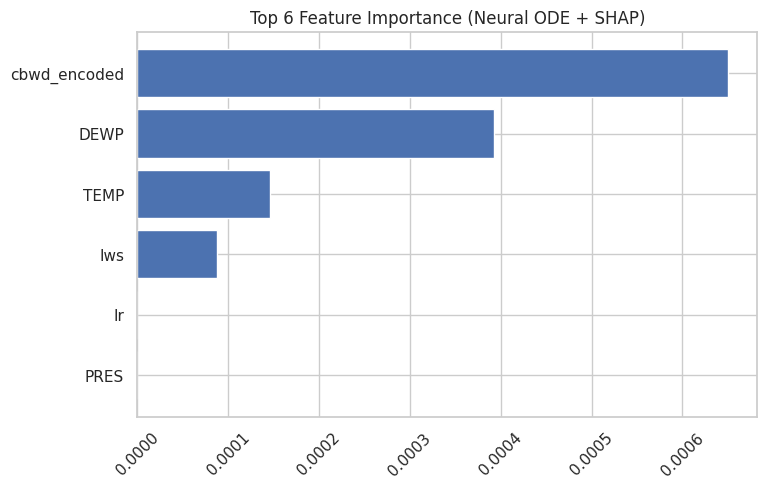

In [227]:
import matplotlib.pyplot as plt
import numpy as np

# get top 6
top_idx = np.argsort(final_importance)[-6:]

plt.figure(figsize=(8,5))
plt.barh(np.array(top_features)[top_idx], final_importance[top_idx])
plt.xticks(rotation=45)
plt.title("Top 6 Feature Importance (Neural ODE + SHAP)")
plt.show()